In [21]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.mask import mask
from shapely.geometry import box
import matplotlib.pyplot as plt
from rasterio.plot import show
import pandas as pd
import math

def geo_to_pixel(geo_x, geo_y, transform):
    """Convert geographic coordinates to pixel coordinates."""
    col = int((geo_x - transform.c) / transform.a)
    row = int((geo_y - transform.f) / transform.e)
    return row, col

def pixel_to_geo(row, col, transform):
    """Convert pixel coordinates to geographic coordinates."""
    geo_x = transform.c + col * transform.a
    geo_y = transform.f + row * transform.e
    return geo_x, geo_y



In [22]:
tif_path = "../../data/aez/aez_v9v2_CRUTS32_Hist_8110_100_avg.tif"
src = rasterio.open(tif_path) 

gdf = gpd.read_file("../../data/gpkgs/haie_2024_france_patches_2024_merged.gpkg")


print(f"CRS: {src.crs}")
print(f"Transform: {src.transform}")
print(f"Shape: {src.shape}")
print(f"Bounds: {src.bounds}")

np.unique(src.read())

CRS: EPSG:4326
Transform: | 0.01, 0.00,-180.00|
| 0.00,-0.01, 90.00|
| 0.00, 0.00, 1.00|
Shape: (21600, 43200)
Bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57], dtype=uint8)

In [23]:
src.crs.linear_units

'unknown'

In [24]:

def extract_patches_from_geotiff(src, gdf_patches,ensure_window=True):
    if gdf_patches.crs != src.crs:
        print(f"Reprojecting from {gdf_patches.crs} to {src.crs}")
        gdf_patches = gdf_patches.to_crs(src.crs)
    
    patches_data = []
    
    for idx, patch in gdf_patches.iterrows():
        try:
            
            bounds = patch.geometry.bounds  
            row_min, col_min = geo_to_pixel(bounds[0], bounds[3], src.transform)
            row_max, col_max = geo_to_pixel(bounds[2], bounds[1], src.transform)
            window = rasterio.windows.from_bounds(*bounds, transform=src.transform)

            if ensure_window:
                col_start = int(math.floor(window.col_off))
                row_start = int(math.floor(window.row_off))
                col_end = int(math.ceil(window.col_off + window.width))
                row_end = int(math.ceil(window.row_off + window.height))
                
                width = max(1, col_end - col_start)
                height = max(1, row_end - row_start)
                
                window = rasterio.windows.Window(col_off=col_start, row_off=row_start, width=width, height=height)
            window_img = src.read(1,window=window) 
            

            patches_data.append({
                'patch_id': idx,
                'pixel_data': window_img.flatten(),
                'pixel_bounds': (row_min, row_max, col_min, col_max),
                'geo_bounds': bounds,
            })
            
        except Exception as e:
            print(f"Error processing patch {idx}: {e}")
    
    return patches_data




In [25]:
def get_zone_classification(gdf, tif_path, clr_path):
    print(f"Reading from file {tif_path}")
    src = rasterio.open(tif_path) 
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")
    print(f"Shape: {src.shape}")
    print(f"Bounds: {src.bounds}")
    print(f"Unique:{np.unique(src.read())}")

    pixel_data_df = pd.DataFrame(extract_patches_from_geotiff(src, gdf))

    class_index_to_class_label = {}
    with open(clr_path, "r") as infile:
        for line in infile:
            parts = line.strip().split()
            class_index_to_class_label[int(parts[0])] = " ".join(parts[5:])

    class_index_to_class_label[0] = "Unclassified"

    def get_majority_nonzero_element(arr, remove_zero=True):
        if remove_zero:
            arr = arr[arr != 0]
        if len(arr) == 0:
            return 0
        values, counts = np.unique(arr, return_counts=True)

        return values[np.argmax(counts)]

    classes = pixel_data_df["pixel_data"].apply(lambda x: get_majority_nonzero_element(x, remove_zero=True))
    classes = [class_index_to_class_label[c] for c in classes]
    return classes
aez_classes = get_zone_classification(gdf, "../../data/aez/aez_v9v2_CRUTS32_Hist_8110_100_avg.tif", "LR/aez/AEZ_57classes.clr")
mst_classes = get_zone_classification(gdf, "../../data/aez/mst_class_CRUTS32_Hist_8110_100_avg.tif", "LR/aez/MoistureRegime_class.clr")
thz_classes = get_zone_classification(gdf, "../../data/aez/thz_class_CRUTS32_Hist_8110_100_avg.tif", "LR/aez/ThermalRegime_class.clr")

Reading from file ../../data/aez/aez_v9v2_CRUTS32_Hist_8110_100_avg.tif
CRS: EPSG:4326
Transform: | 0.01, 0.00,-180.00|
| 0.00,-0.01, 90.00|
| 0.00, 0.00, 1.00|
Shape: (21600, 43200)
Bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Unique:[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57]


FileNotFoundError: [Errno 2] No such file or directory: 'LR/aez/AEZ_57classes.clr'

In [ ]:
bounds = gdf.total_bounds
src = rasterio.open("LR/aez/mst_class_CRUTS32_Hist_8110_100_avg.tif")
window = rasterio.windows.from_bounds(*bounds, transform=src.transform)
window_img = src.read(1, window=window) 

np.unique(window_img)

pixel_data_df = pd.DataFrame(extract_patches_from_geotiff(src, gdf))

In [ ]:
pixel_data_df

,patch_id,pixel_data,pixel_bounds,geo_bounds
0,0,[5],"(498, 498, 2098, 2098)","(-5.116647565200277, 48.45542262813023, -5.105..."
1,1,"[5, 5]","(498, 498, 2098, 2099)","(-5.093650693926818, 48.45542262813023, -5.082..."
2,2,[5],"(498, 498, 2099, 2099)","(-5.082152258290087, 48.45542262813023, -5.070..."
3,3,[6],"(499, 499, 2102, 2102)","(-4.794691367371841, 48.363830646348795, -4.78..."
4,4,[6],"(499, 499, 2102, 2102)","(-4.794691367371841, 48.40201402069609, -4.783..."
...,...,...,...,...
603559,603559,[5],"(572, 572, 2274, 2274)","(9.543857871630312, 42.28494030679162, 9.55535..."
603560,603560,[5],"(572, 572, 2274, 2274)","(9.543857871630312, 42.29344636675015, 9.55535..."
603561,603561,[5],"(572, 572, 2274, 2274)","(9.543857871630312, 42.30195127806909, 9.55535..."
603562,603562,[5],"(572, 572, 2274, 2274)","(9.543857871630312, 42.31045504071619, 9.55535..."


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_class_distribution(classes,
                            title="Distribution of AEZ Class Across Hedgerow Data",
                            verbose=False):
    values,counts = np.unique(classes, return_counts=True)

    sorted_indices = np.argsort(counts)[::-1]
    sorted_values = values[sorted_indices]
    sorted_counts = counts[sorted_indices]

    n_classes = len(sorted_values)
    colors = plt.cm.tab20c(np.linspace(0, 1, n_classes)) if n_classes <= 20 else plt.cm.hsv(np.linspace(0, 1, n_classes))



    _, ax = plt.subplots(figsize=(16, 8))



    bars = ax.bar(range(n_classes), sorted_counts, color=colors, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Class Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(range(n_classes), fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    legend_labels = [f"{label[:50]}{'...' if len(label) > 50 else ''}" 
                    for _, label in enumerate(sorted_values)]

    ax.legend(bars, legend_labels, 
            loc='center left', 
            bbox_to_anchor=(1.02, 0.5),
            fontsize=9,
            framealpha=0.9,
            title='Class Labels',
            title_fontsize=11)

    plt.tight_layout()
    plt.show()
    if verbose:
        print(f"\nTotal number of unique classes: {n_classes}")
        print(f"Most common class: {sorted_values[0]} ({sorted_counts[0]} occurrences)")
        print(f"Least common class: {sorted_values[-1]} ({sorted_counts[-1]} occurrences)")



In [ ]:
gdf["aez_class"] = aez_classes
gdf["thz_class"] = thz_classes
gdf["mst_class"] = mst_classes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def plot_geographic_distribution(gdf, 
                                 key="aez_class", 
                                 title="Geographic Distribution of {}", 
                                 xlabel="Latitude", 
                                 ylabel="Longitude",
                                 xticks=None,
                                 yticks=None,
                                 legend=True):
    data = gdf[key]
    if type(data.iloc[0]) == np.int64:
        data = data[data >= 0]
    values,counts = np.unique(data, return_counts=True)

    sorted_indices = np.argsort(counts)[::-1]
    sorted_values = values[sorted_indices]
    print(counts)

    n_classes = len(sorted_values)
    if n_classes < 10:
        colors = plt.cm.tab10(np.arange(n_classes))
    else:
        colors = plt.cm.tab20(np.arange(n_classes) % 20)
        if n_classes > 20:
            colors2 = plt.cm.Set3(np.arange(n_classes - 20) % 12)
            colors = np.vstack([colors, colors2])

    class_to_color = {class_name: colors[i] for i, class_name in enumerate(sorted_values)}

    gdf['plot_color'] = gdf[key].map(class_to_color)

    fig, ax = plt.subplots(figsize=(18, 12))

    if gdf.geometry.geom_type.iloc[0] == 'Point':
        for class_name in sorted_values:
            class_data = gdf[gdf[key] == class_name]
            if len(class_data) > 0:
                class_data.plot(ax=ax, 
                            color=class_to_color[class_name],
                            markersize=15,
                            edgecolor='black',
                            linewidth=0.2,
                            alpha=0.7,
                            label=class_name)
    else:
        for class_name in sorted_values:
            class_data = gdf[gdf[key] == class_name]
            if len(class_data) > 0:
                class_data.plot(ax=ax,
                            color=class_to_color[class_name],
                            edgecolor='black',
                            linewidth=0.1,
                            alpha=0.8,
                            label=class_name)

    # Customize the plot
    ax.set_xlabel(xlabel, fontsize=24, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=24, fontweight='bold')
    ax.set_title(title.format(key), fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal')
    ax.tick_params("both", labelsize=12)

    if xticks is not None:
        ax.set_xticklabels(xticks)
    if yticks is not None:
        ax.set_yticklabels(yticks)

    # Create legend with the same colors and order as histogram
    legend_labels = [f"{i}: {str(label)[:45]}{'...' if len(str(label)) > 45 else ''}" 
                    for i, label in enumerate(sorted_values)]

    # Create custom legend handles
    from matplotlib.patches import Patch
    if legend:
        legend_handles = [Patch(facecolor=colors[i], edgecolor='black', linewidth=0.5) 
                        for i in range(n_classes)]

        ax.legend(legend_handles, legend_labels,
                loc='center left',
                bbox_to_anchor=(1.02, 0.5),
                fontsize=14,
                framealpha=0.95,
                title='Class Labels',
                title_fontsize=10,
                ncol=1)

    plt.tight_layout()
    plt.show()

    # Print class distribution info
    print(f"\nClass distribution summary:")
    print(f"Total points/polygons plotted: {len(gdf)}")
    print(f"\nTop 5 classes by count:")
    for i in range(min(5, len(sorted_values))):
        count = len(gdf[gdf[key] == sorted_values[i]])
        pct = 100 * count / len(gdf)
        print(f"  {sorted_values[i]}: {count} ({pct:.1f}%)")




In [ ]:
import shapely
patch_size = 1280

def create_checkerboard_with_gaps(gdf, 
                                  patch_size=patch_size,
                                  patches_per_cell=12,
                                  patches_between_cells=2,
                                  epsilon=10):
    gdf_projected = gdf.to_crs('EPSG:3857')
    xmin, ymin, xmax, ymax = gdf_projected.total_bounds
    print(gdf_projected.total_bounds)

    patches = []

    for x0 in np.arange(xmin, xmax, patch_size * (patches_per_cell + patches_between_cells) + epsilon):
        for y0 in np.arange(ymin, ymax, patch_size * (patches_per_cell + patches_between_cells) + epsilon):
            x1 = x0 + patch_size * patches_per_cell
            y1 = y0 + patch_size * patches_per_cell
            patches.append(shapely.geometry.Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)]))
    
    patches_gdf = gpd.GeoDataFrame(geometry=patches, crs=gdf_projected.crs)
    patches_gdf = patches_gdf.to_crs("EPSG:4326")

    return patches_gdf

PATCHES_PER_CELL = 12
PATCHES_BETWEEN_CELLS = 3

patches_gdf = create_checkerboard_with_gaps(gdf, patches_per_cell=PATCHES_PER_CELL, patches_between_cells=PATCHES_BETWEEN_CELLS)

[-569582.60152674 5066798.14641221 1064977.39847326 6634798.14641221]


In [ ]:
import random
from collections import defaultdict
N_FOLDS = 5

import random
from collections import defaultdict

gap_size = patch_size * PATCHES_BETWEEN_CELLS

neighbor_distance = patch_size * ( PATCHES_BETWEEN_CELLS + PATCHES_PER_CELL * 0.5)

patches_gdf = patches_gdf.to_crs('EPSG:3857')
patches_gdf['buffered'] = patches_gdf.geometry.to_crs("EPSG:3857").buffer(neighbor_distance)

temp_gdf = patches_gdf.copy()
temp_gdf = temp_gdf.set_geometry('buffered')

neighbors = gpd.sjoin(temp_gdf, temp_gdf.copy(), predicate='intersects')

adjacency = defaultdict(set)
for idx, row in neighbors.iterrows():
    if idx != row['index_right']:
        adjacency[idx].add(row['index_right'])

patches_gdf = patches_gdf.drop(columns=['buffered'])

folds = {}
indices = list(patches_gdf.index)
random.shuffle(indices)



In [ ]:
for idx in indices:
    adjacent_folds = {folds[adj] for adj in adjacency[idx] if adj in folds}
    
    available_folds = [f for f in range(N_FOLDS) if f not in adjacent_folds]
    if len(available_folds) == 0:
        folds[idx] = random.choice([f for f in range(N_FOLDS)])
    else:
        folds[idx] = random.choice(available_folds)

patches_gdf["folds"] = patches_gdf.index.map(folds)

In [ ]:
fold_dict = {}

for i in range(N_FOLDS):
    fold_dict[i] = shapely.unary_union(
        patches_gdf[patches_gdf["folds"] == i]["geometry"]
    )

len(fold_dict[0].geoms)


1415

In [ ]:
folds_list = [fold_dict[i] for i in range(len(fold_dict))]

In [ ]:
folds_list

[<MULTIPOLYGON (((-515802.602 5101368.146, -515802.602 5086008.146, -531162.6...>,
 <MULTIPOLYGON (((-515802.602 5082158.146, -515802.602 5066798.146, -531162.6...>,
 <MULTIPOLYGON (((-438962.602 5082158.146, -438962.602 5066798.146, -454322.6...>,
 <MULTIPOLYGON (((-496592.602 5082158.146, -496592.602 5066798.146, -511952.6...>,
 <MULTIPOLYGON (((-554222.602 5082158.146, -554222.602 5066798.146, -569582.6...>]

In [ ]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
def categorize_using_bounds(bounds_list, gdf, crs="EPSG:3857"):
    gdf = gdf.to_crs(crs) 
    tree = shapely.STRtree(gdf.geometry)
    assignments = [-1] * len(gdf)

    for i in range(len(bounds_list)):
        current_bounds = bounds_list[i]

        new_indices = tree.query(current_bounds, predicate="intersects")
        new_indices = set(new_indices)

        for j in new_indices:
            assignments[j] = i

    return assignments

In [ ]:
gdf["fold"] = categorize_using_bounds(folds_list, gdf)

In [ ]:
gdf["fold"]

0         3
1         3
2         3
3        -1
4        -1
         ..
603559    4
603560    4
603561    4
603562    4
603563    4
Name: fold, Length: 603564, dtype: int64

In [ ]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

[-569582.60152674 5066798.14641221 1064977.39847326 6634798.14641221]
[ 880  571  957 1146 1144]


/tmp/ipykernel_149247/2474431402.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks)
/tmp/ipykernel_149247/2474431402.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticks)


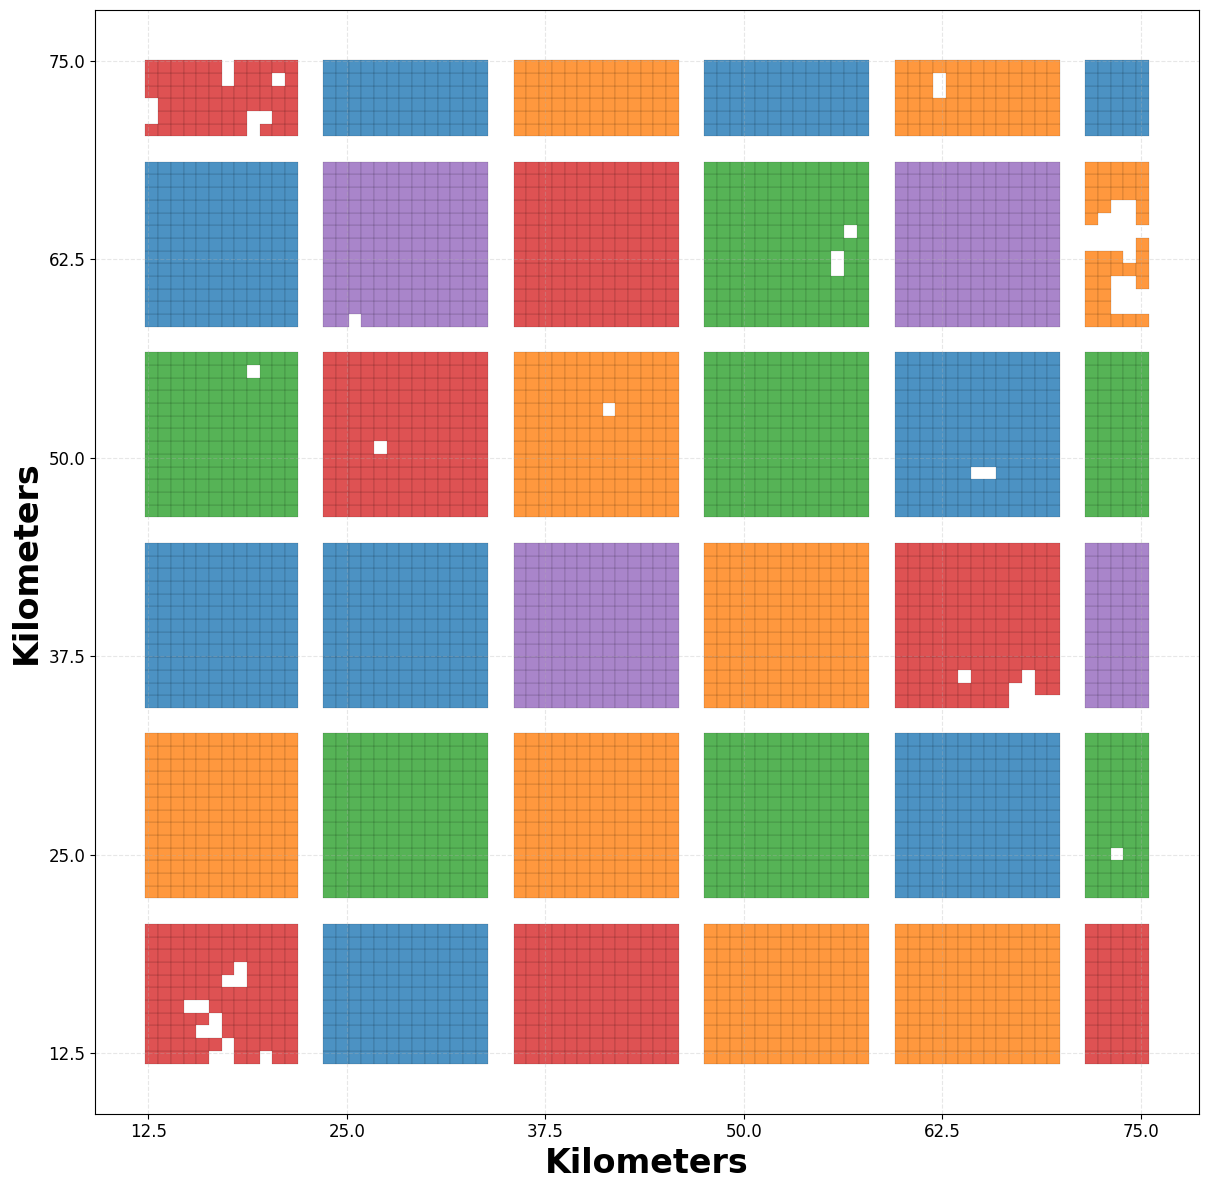


Class distribution summary:
Total points/polygons plotted: 6163

Top 5 classes by count:
  3: 1146 (18.6%)
  4: 1144 (18.6%)
  2: 957 (15.5%)
  0: 880 (14.3%)
  1: 571 (9.3%)


In [ ]:
sub_gdf = gdf.to_crs("EPSG:3857")

print(sub_gdf.total_bounds)
XMIN=200000
XMAX=300000
YMIN=5800000
YMAX=5900000

bbox = shapely.box(
    xmin=200000,    # Middle of x-range (-569k to 1,064k)
    xmax=300000,
    ymin=5800000,   # Middle of y-range (5,066k to 6,634k)
    ymax=5900000
)
sub_gdf= sub_gdf[sub_gdf["geometry"].intersects(bbox)]
len(sub_gdf)

XRANGE = XMAX - XMIN
YRANGE = YMAX - YMIN
plot_geographic_distribution(sub_gdf, key="fold", title="", xlabel="Kilometers", ylabel="Kilometers", 
                             xticks=np.arange(0,XRANGE/1000,XRANGE/8000), yticks=np.arange(0,YRANGE/1000,YRANGE/8000)
                             , legend=False)


[91395 87364 92372 91602 90751]


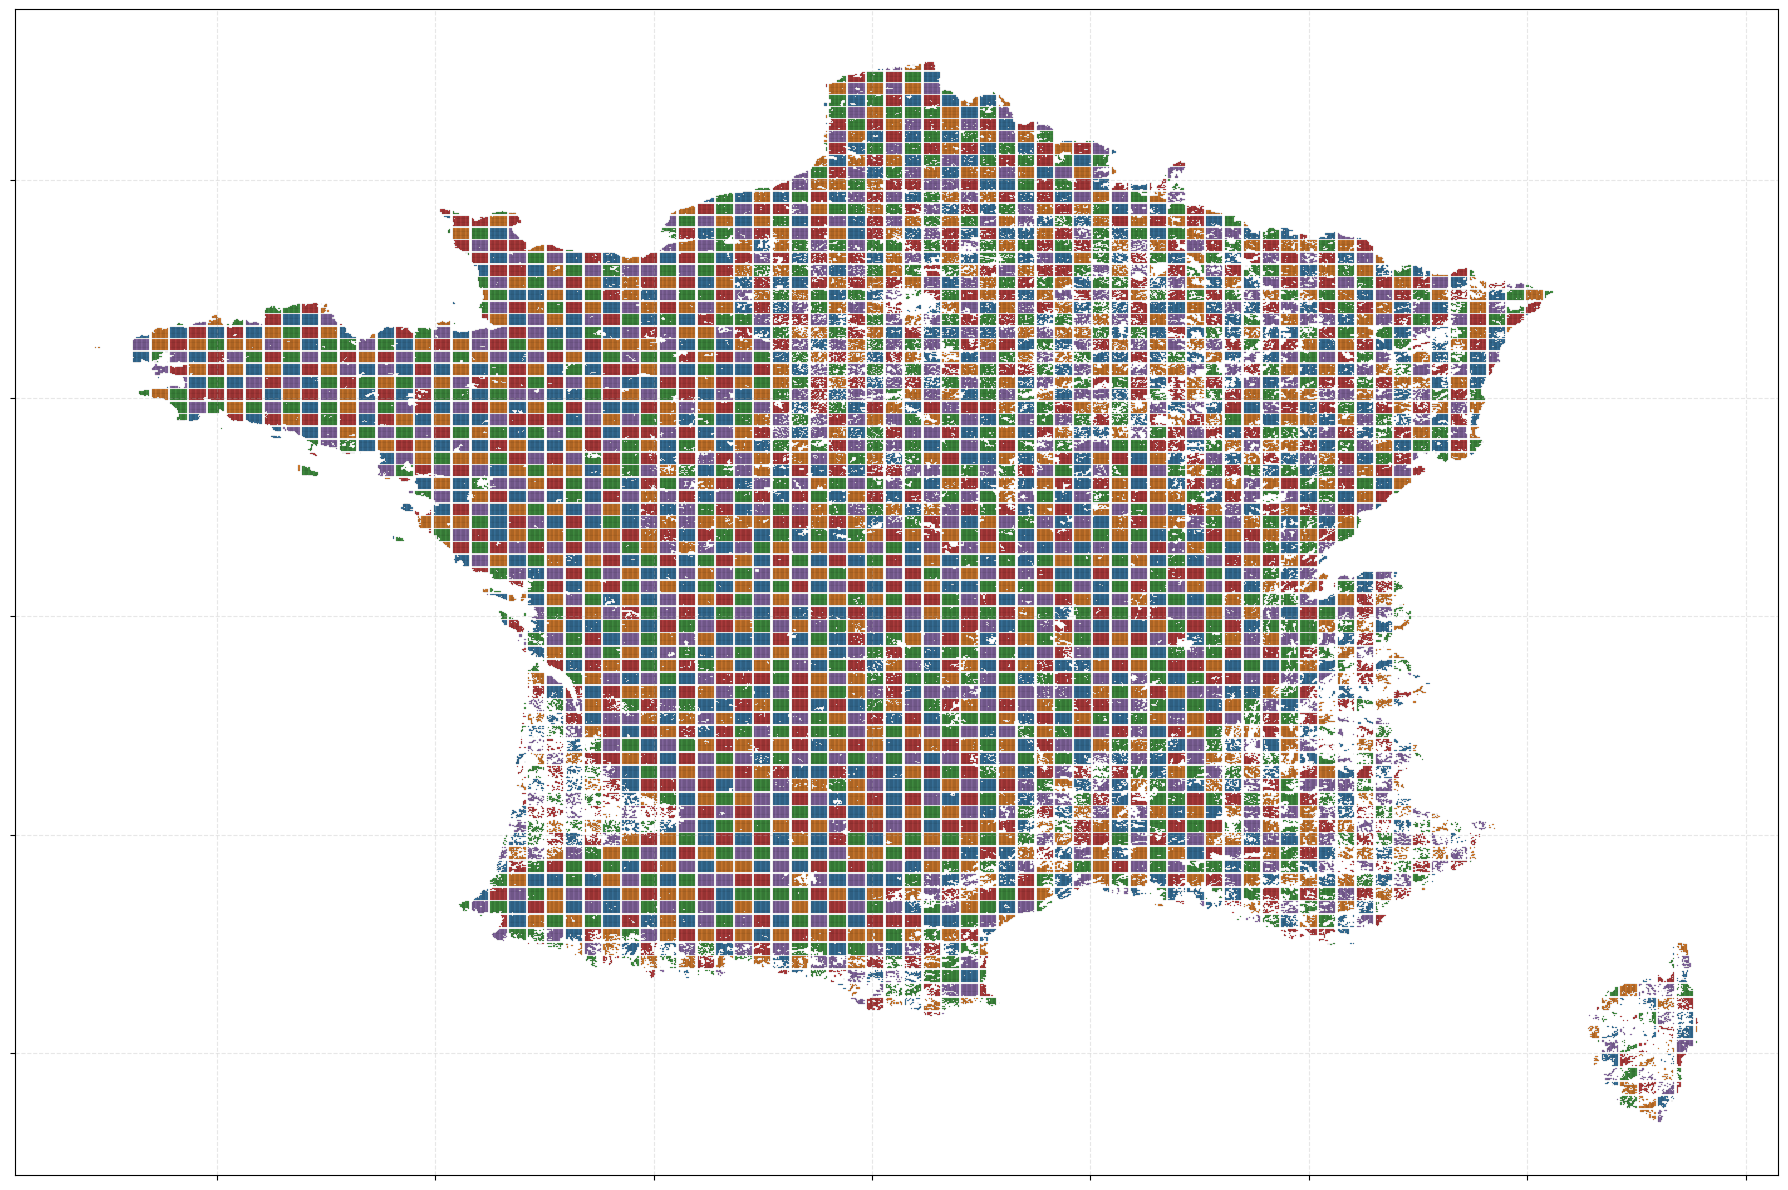


Class distribution summary:
Total points/polygons plotted: 603564

Top 5 classes by count:
  2: 92372 (15.3%)
  3: 91602 (15.2%)
  0: 91395 (15.1%)
  4: 90751 (15.0%)
  1: 87364 (14.5%)


In [ ]:
plot_geographic_distribution(gdf, key="fold", title="", xlabel="", ylabel="", legend=False, xticks=[], yticks=[])


In [ ]:
len(gdf)

603564

In [ ]:
np.arange(0,(YMAX-YMIN),(YMAX-YMIN)/6)

array([    0.        , 16666.66666667, 33333.33333333, 50000.        ,
       66666.66666667, 83333.33333333])

In [ ]:
gdf["fold"].iloc[0]

np.int64(3)

In [ ]:
def get_value_counts(gdf,sections):
    assignments = categorize_using_bounds(sections, gdf)

    value_counts = pd.Series(assignments).value_counts().sort_index()
    if -1 in value_counts.index:
        value_counts = value_counts.drop(index=[-1])
    value_counts = value_counts.reindex(list(range(
            0,
            len(sections)+1)),
            fill_value=0)
    
    return value_counts

def drop_sparse_sections(value_counts,mean_count,sections,threshold):

    pct_of_mean = value_counts.apply(lambda x: x / mean_count).values

    drops = [
        (i,sec) for (i,sec) in enumerate(sections) if pct_of_mean[i] >= threshold
    ]

    return [s for _,s in drops], [i for i,_ in drops]


def create_sections(gdf, 
                    rows=2, 
                    cols=2, 
                    epsilon=1, 
                    sanity_check=False,
                    buffer_pct=None,
                    show_post_drop=False,
                    threshold=0,
                    cmap=None):
    #TODO return the buffer distance between tiles
    gdf = gdf.to_crs("EPSG:3857")
    minx, miny, maxx, maxy = gdf.total_bounds
    step_x = (maxx - minx ) / (cols)
    step_y = (maxy - miny ) / (rows)
    x_steps = np.arange(minx, maxx + step_x-epsilon, step_x)
    y_steps = np.arange(miny, maxy + step_y-epsilon, step_y)
    if buffer_pct:
        print(f"BUFFER DISTANCE: {int(buffer_pct * step_x)} M horizontally, {int(buffer_pct * step_y)} M vertically")
    sections = []
    for i in range(len(y_steps)-1):
        for j in range(len(x_steps)-1):
            if not buffer_pct:
                sec = shapely.geometry.box(x_steps[j], y_steps[i], x_steps[j+1], y_steps[i+1])
                
            else:
                buffer_amt_x = step_x * (buffer_pct/2)
                buffer_amt_y = step_y * (buffer_pct/2)
                sec = shapely.geometry.box(x_steps[j] + buffer_amt_x, 
                                           y_steps[i] + buffer_amt_y, 
                                           x_steps[j+1] - buffer_amt_x, 
                                           y_steps[i+1] - buffer_amt_y)
            sections.append(sec)

    sections = sorted(
        sorted(sections, key=lambda sec: sec.centroid.x),
        key=lambda sec: sec.centroid.y,
        reverse=True
        )
    if sanity_check:
        colors = cmap if cmap else plt.cm.plasma(np.linspace(0, 1, len(sections)))
        value_counts = get_value_counts(gdf, sections)
        mean_count = value_counts.mean()
        lines = [
            [mean_count, "Mean count", "orange"],
           
        ]

        if threshold:
            lines.append( [threshold * mean_count, "Inclusion threshold", "red"])
        if show_post_drop:
            _,axs = plt.subplots(2,2,figsize=(13,10))
           
            sections_post_drop, inds_post_drop = drop_sparse_sections(
                value_counts,
                mean_count,
                sections,
                threshold
            )


            colors_post_drop = colors[inds_post_drop]
            value_counts_post_drop = value_counts.iloc[inds_post_drop]
            
            visualize_sections(axs[0][0], sections, gdf, colors)
            graph_section_value_counts(axs[0][1], value_counts, colors,lines)
            
            visualize_sections(axs[1][0], sections_post_drop, gdf, colors_post_drop,inds=inds_post_drop,
                               title="Tiles overtop of geographic data distribution after dropping sparse tiles")
            graph_section_value_counts(axs[1][1], value_counts_post_drop, colors_post_drop, lines,
                                       title="Count of datapoints overlapping each tile after dropping sparse tiles")
        else:
            _,axs = plt.subplots(1,2,figsize=(18,7.5))
            axs[0].set_xticks([])
            axs[0].set_yticks([])
            
            visualize_sections(axs[0], sections, gdf, colors)
            graph_section_value_counts(axs[1], value_counts, colors,lines)
            

        plt.tight_layout()
        plt.show()
    return sections


def visualize_sections(ax,sections,gdf,colors=None,inds=None,title="Tiles overtop of geographic data distribution"):
    centroids = gdf.geometry.centroid
    x,y = centroids.apply(lambda var: var.x), centroids.apply(lambda var: var.y)
    ax.scatter(x,y)
    if not inds:
        inds = [i for i in range(len(sections))]
    if colors is None:
        colors = ["red"] * len(sections)
    for i,q in enumerate(sections):
        x,y = q.exterior.xy
        ax.plot(x,y, color=colors[i])
        ax.text(q.centroid.x,
                 q.centroid.y,
                 str(inds[i]),
                 size=12,
                 color=colors[i],
                 horizontalalignment="center")
    minx, miny, maxx, maxy = gdf.total_bounds
    we = shapely.geometry.box(minx,miny, maxx,maxy)
    nx,ny = we.exterior.xy
    ax.plot(nx,ny,color="blue")
    ax.set_title(title)
    

def graph_section_value_counts(ax, value_counts, colors, lines,title="Count of datapoints overlapping each tile"):
   
    idxs = value_counts.index
    vals = value_counts.values
    ax.set_xticks(idxs)
    ax.bar(x=idxs, height=vals,color=colors)

    for height,lab,c in lines:
        ax.axhline(y=height,color=c,label=lab)
    ax.legend()
    ax.set_title(title)
# four_by_four = create_sections(gdf, rows=4, cols=4, 
#                                epsilon=1, 
#                                buffer_pct=0.1, 
#                                sanity_check=True,
#                                show_post_drop=True)

# five_by_five = create_sections(gdf, rows=5, cols=5, epsilon=1, buffer_pct=0.1, sanity_check=True, show_post_drop=True)
# six_by_six = create_sections(gdf, rows=6, cols=6, epsilon=1, buffer_pct=0.1, sanity_check=True, show_post_drop=True)


BUFFER DISTANCE: 27242 M horizontally, 26133 M vertically


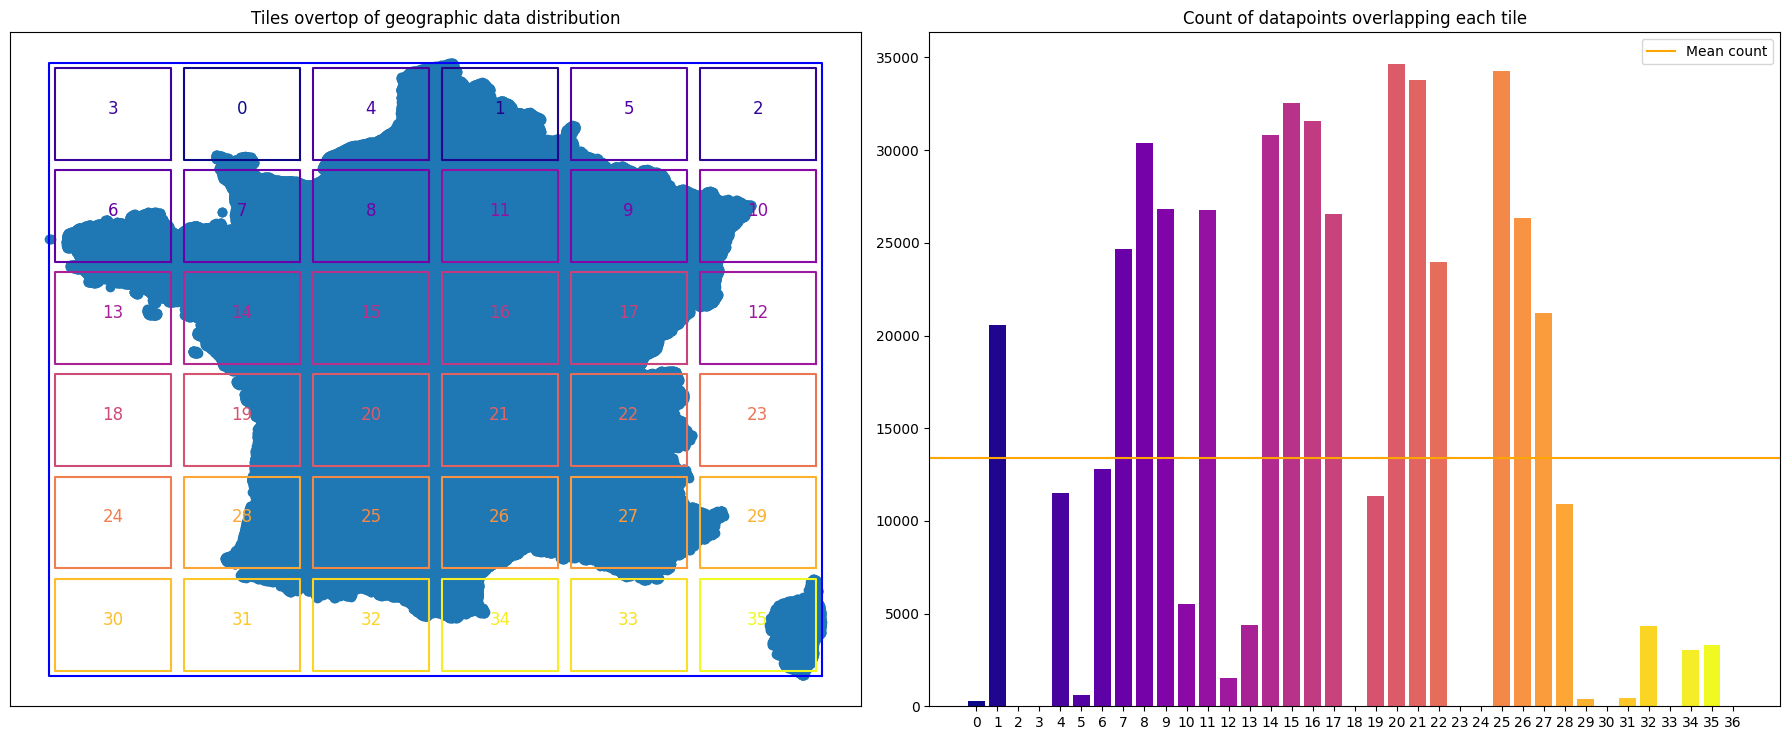

In [ ]:
tiles = create_sections(gdf, rows=6, cols=6, epsilon=1, buffer_pct=0.1, threshold=0, sanity_check=True)


<function __main__.visualize_sections(ax, sections, gdf, colors=None, inds=None, title='Tiles overtop of geographic data distribution')>

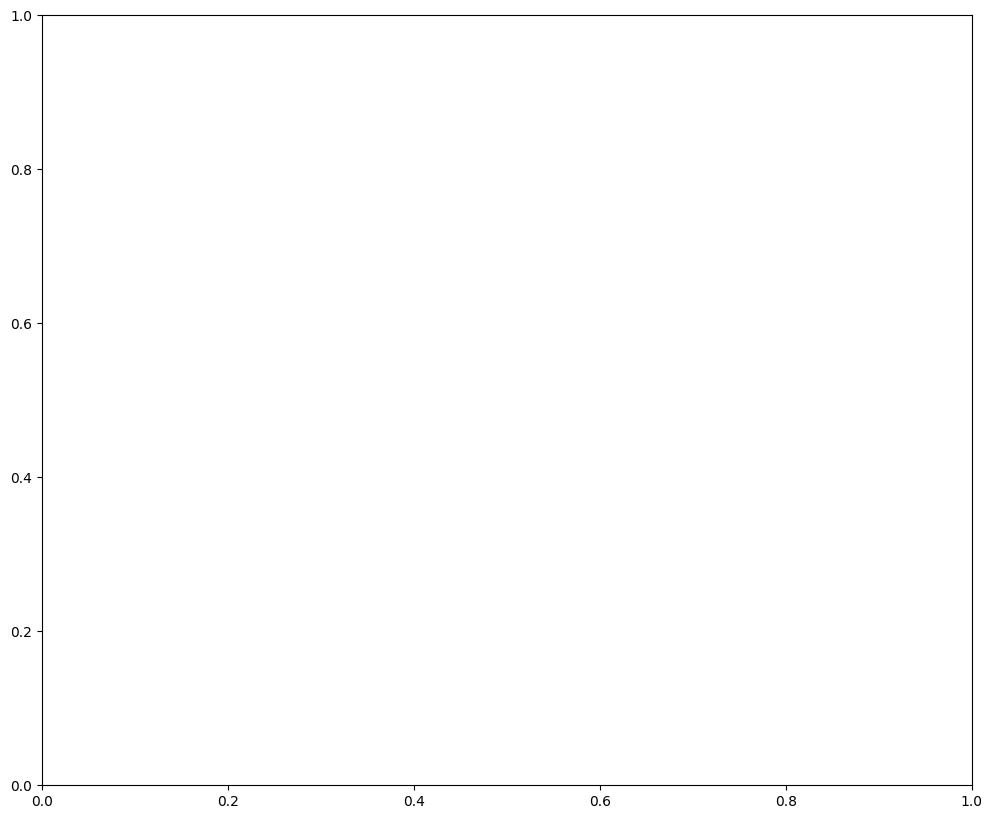

In [122]:
fig, ax = plt.subplots(figsize=(12, 10))
visualize_sections

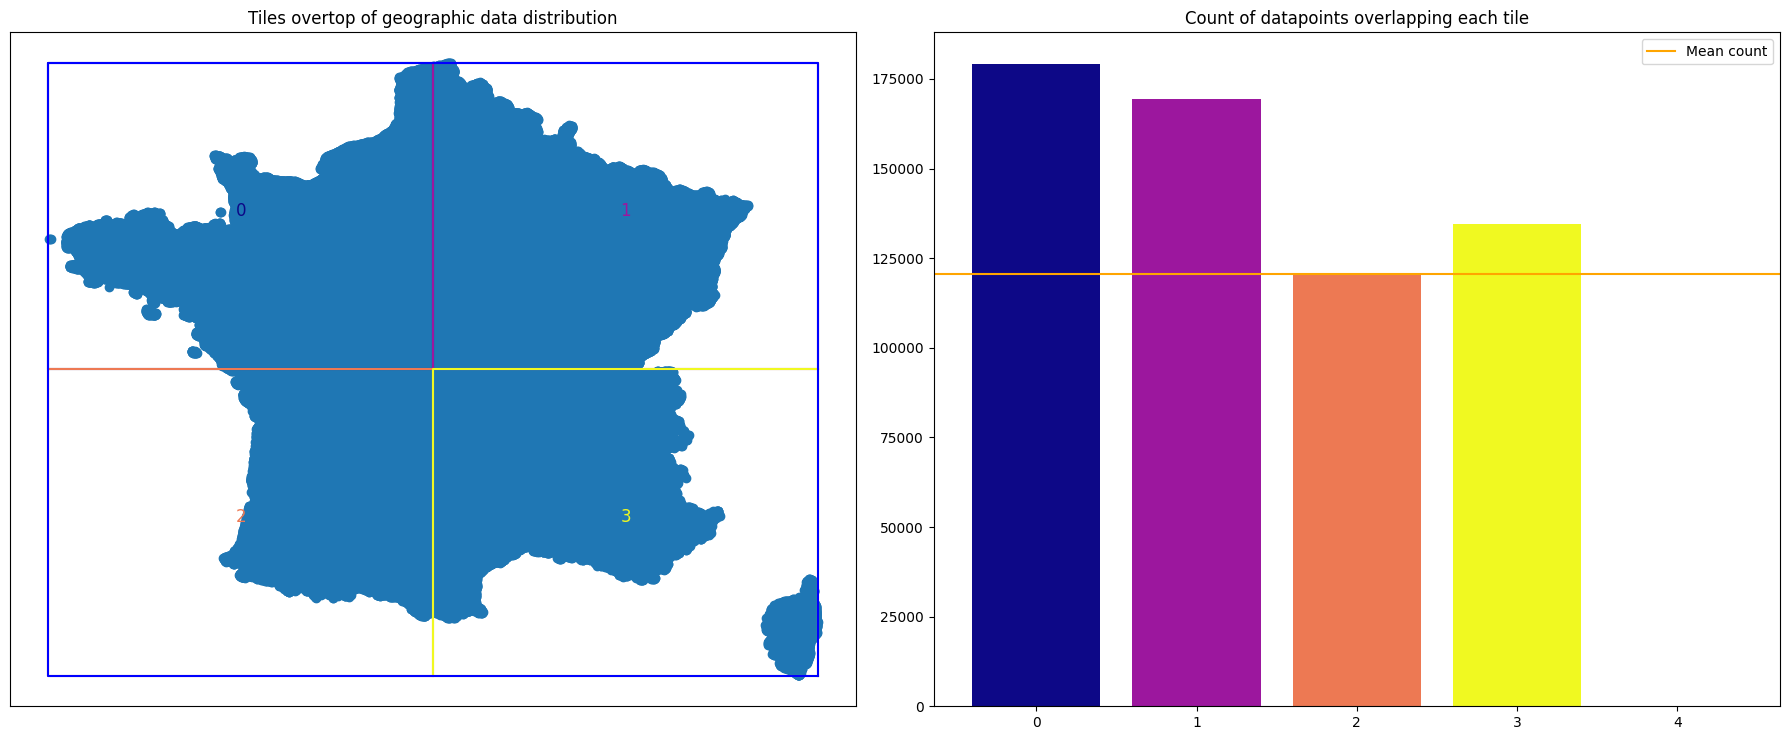

In [123]:
quadrants = create_sections(gdf, cols=2, rows=2, sanity_check=True)
quadrant_assignments = categorize_using_bounds(quadrants, gdf)
gdf["quadrant"] = quadrant_assignments

In [124]:
sixteenths = create_sections(gdf, cols=4, rows=4, sanity_check=True)
sixteenth_assignments = categorize_using_bounds(quadrants, gdf)
gdf["sixteenth"] = sixteenth_assignments

KeyboardInterrupt: 

BUFFER DISTANCE: 27242 M horizontally, 26133 M vertically


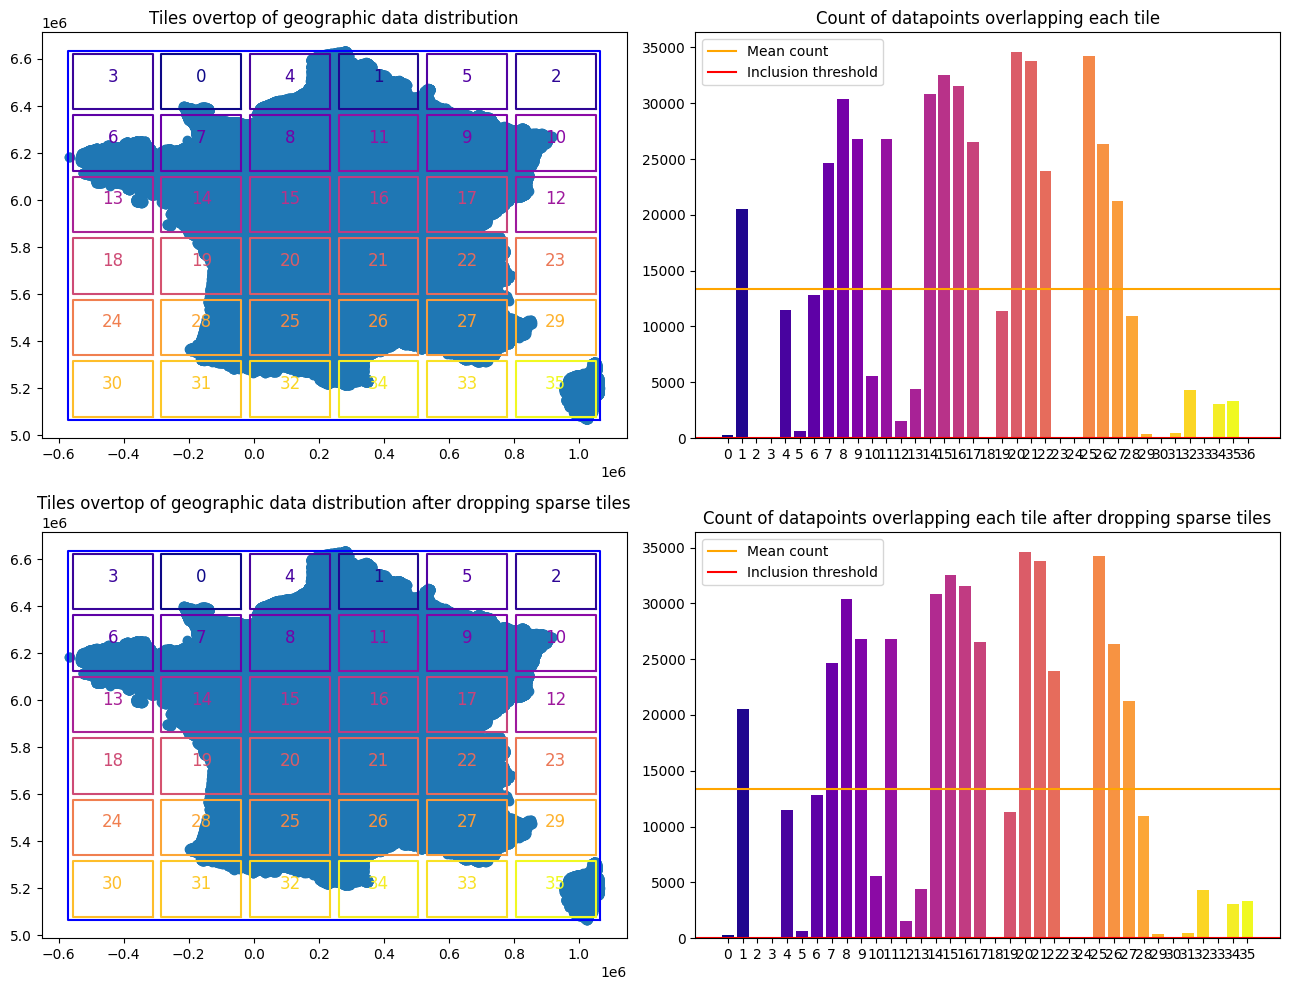

In [ ]:
tiles = create_sections(gdf, rows=6, cols=6, epsilon=1, buffer_pct=0.1, sanity_check=True, show_post_drop=True)
tile_assignments = categorize_using_bounds(tiles, gdf)
gdf["tile"] = tile_assignments

BUFFER DISTANCE: 27242 M horizontally, 26133 M vertically


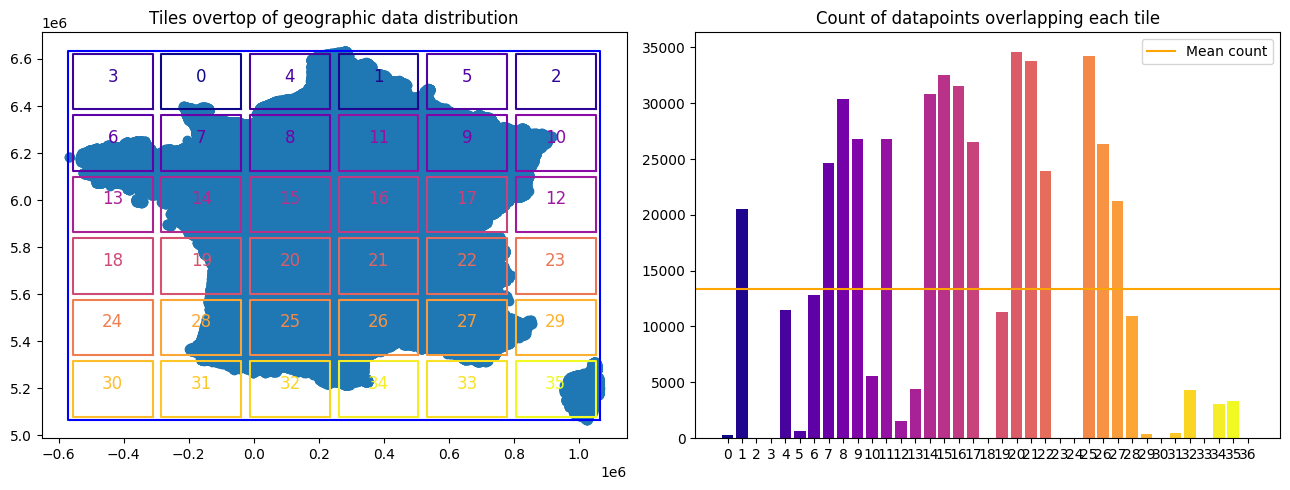

In [ ]:
gdf["tile"]

0        -1
1        -1
2        -1
3         6
4         6
         ..
603559   -1
603560   -1
603561   -1
603562   -1
603563   -1
Name: tile, Length: 603564, dtype: int64

In [ ]:
values,counts = np.unique(gdf["aez_class"], return_counts=True)
pairs = sorted([pair for pair in zip(values,counts)], key=lambda x: x[1], reverse=True)
for p in pairs:
    print(p)

('Temperate, cool; wet, no soil/terrain limitations', np.int64(129001))
('Temperate, cool; moist, no soil/terrain limitations', np.int64(109696))
('Temperate, cool; wet, with soil/terrain limitations', np.int64(103616))
('Temperate, cool; moist, with soil/terrain limitations', np.int64(79465))
('Ample irrigated soils', np.int64(36861))
('Sub-tropics, cool; humid, no soil/terrain limitations', np.int64(26897))
('Sub-tropics, cool; humid, with soil/terrain limitations', np.int64(23548))
('Land with severe soil/terrain limitations', np.int64(20363))
('Sub-tropics, cool; sub-humid, with soil/terrain limitations', np.int64(15694))
('Sub-tropics, mod. cool; humid, no soil/terrain limitations', np.int64(10562))
('Dominantly very steep terrain', np.int64(10532))
('Sub-tropics, mod. cool; humid, with soil/terrain limitations', np.int64(8841))
('Sub-tropics, mod. cool; sub-humid, with soil/terrain limitations', np.int64(7208))
('Dominantly hydromorphic soils', np.int64(6543))
('Sub-tropics, mod.

[103159 101967 104526 105111 105527]


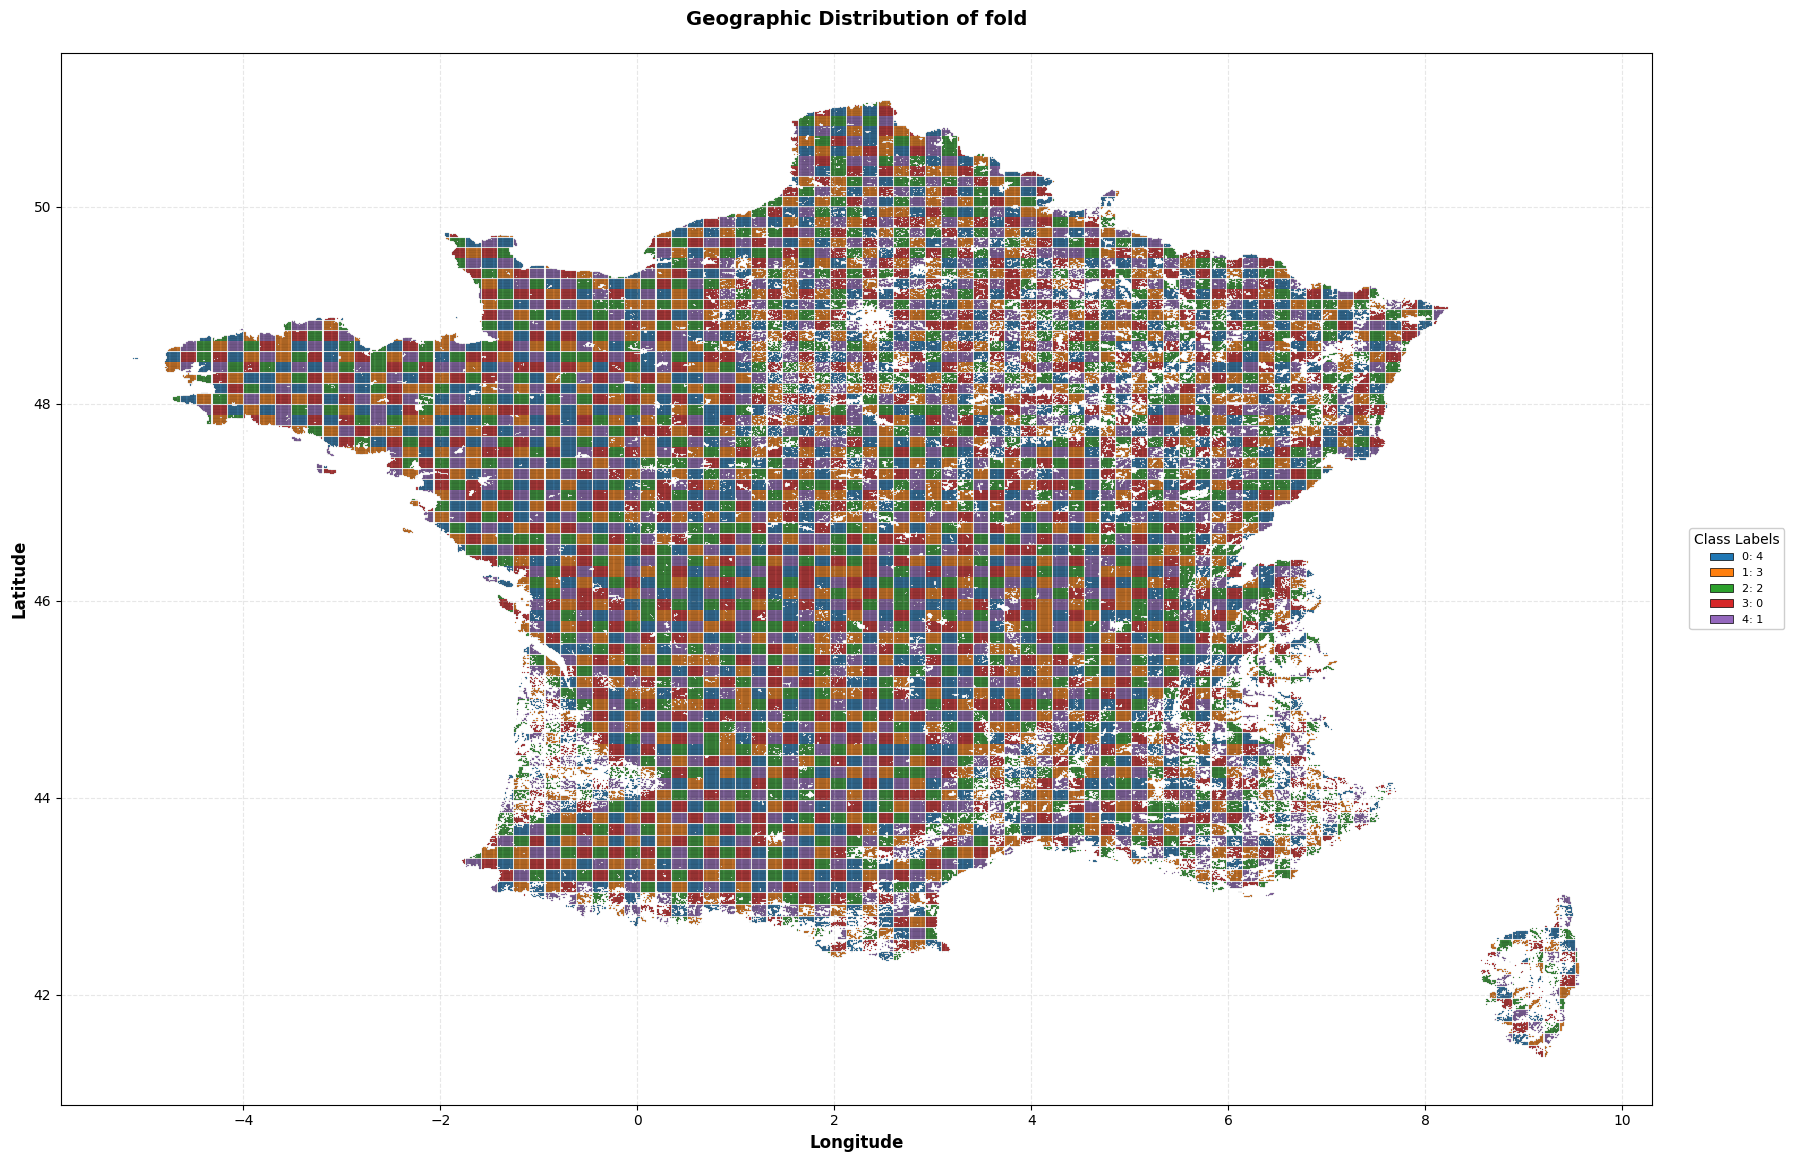


Class distribution summary:
Total points/polygons plotted: 603564

Top 5 classes by count:
  4: 105527 (17.5%)
  3: 105111 (17.4%)
  2: 104526 (17.3%)
  0: 103159 (17.1%)
  1: 101967 (16.9%)


In [ ]:
plot_geographic_distribution(gdf, key="fold")

In [ ]:
gdf.to_file("gpkgs/bda_2024_patches_2024_classified.gpkg")

/home/nathan/Desktop/BDA_integration/.venv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Spatial index (perhaps created with GDAL 3.6.0) of table bda_2024_patches_2024_classified is corrupted. Disabling its use. This file should be recreated or its spatial index recreated
  ogr_write(
